# DishaNifty — Random Forest (Task 8)
Owner: Sujal

Loads the walk-forward tuning results produced by `src/models/rf_model.py`
and presents them: per-fold metrics, best hyperparameters, and confusion
matrices. This notebook does not retrain anything — it reads the CSVs
already saved to `results/` so results stay reproducible and the test
set stays untouched.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.append(str(Path.cwd().parent / "src"))
pd.set_option("display.max_colwidth", None)

## Fold-by-fold results

In [3]:
results = pd.read_csv("../results/rf_fold_results.csv")
results

,fold,best_params,accuracy,macro_f1,precision_down,recall_down,precision_neutral,recall_neutral,precision_up,recall_up
0,1,"{'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}",0.324000,0.287781,0.278689,0.414634,0.142857,0.136364,0.476744,0.330645
1,2,"{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 400}",0.399194,0.289052,0.307692,0.101266,0.368421,0.112903,0.413793,0.785047
2,3,"{'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}",0.383065,0.353572,0.423077,0.351064,0.244444,0.220000,0.408000,0.490385
3,4,"{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}",0.322449,0.221692,0.313364,0.918919,0.200000,0.012658,0.434783,0.108696


In [4]:
print(f"Mean Accuracy: {results['accuracy'].mean():.4f}")
print(f"Mean Macro F1:  {results['macro_f1'].mean():.4f}")

Mean Accuracy: 0.3572
Mean Macro F1:  0.2880


## Macro F1 per fold

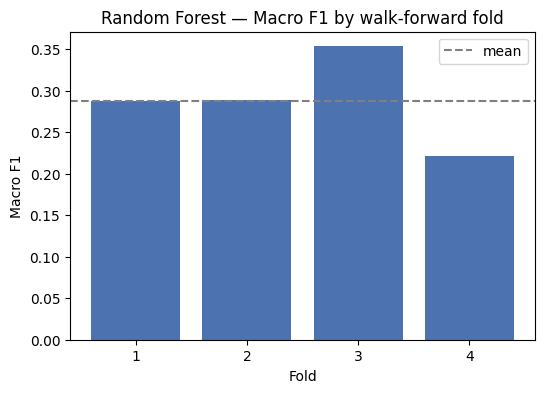

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results['fold'].astype(str), results['macro_f1'], color='#4C72B0')
ax.axhline(results['macro_f1'].mean(), color='gray', linestyle='--', label='mean')
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1")
ax.set_title("Random Forest — Macro F1 by walk-forward fold")
ax.legend()
plt.show()

## Per-class precision / recall per fold

In [6]:
results[['fold', 'precision_down', 'recall_down',
          'precision_neutral', 'recall_neutral',
          'precision_up', 'recall_up']]

,fold,precision_down,recall_down,precision_neutral,recall_neutral,precision_up,recall_up
0,1,0.278689,0.414634,0.142857,0.136364,0.476744,0.330645
1,2,0.307692,0.101266,0.368421,0.112903,0.413793,0.785047
2,3,0.423077,0.351064,0.244444,0.220000,0.408000,0.490385
3,4,0.313364,0.918919,0.200000,0.012658,0.434783,0.108696


## Confusion matrices per fold
Rows = actual, columns = predicted. Class order: 0=DOWN, 1=NEUTRAL, 2=UP.

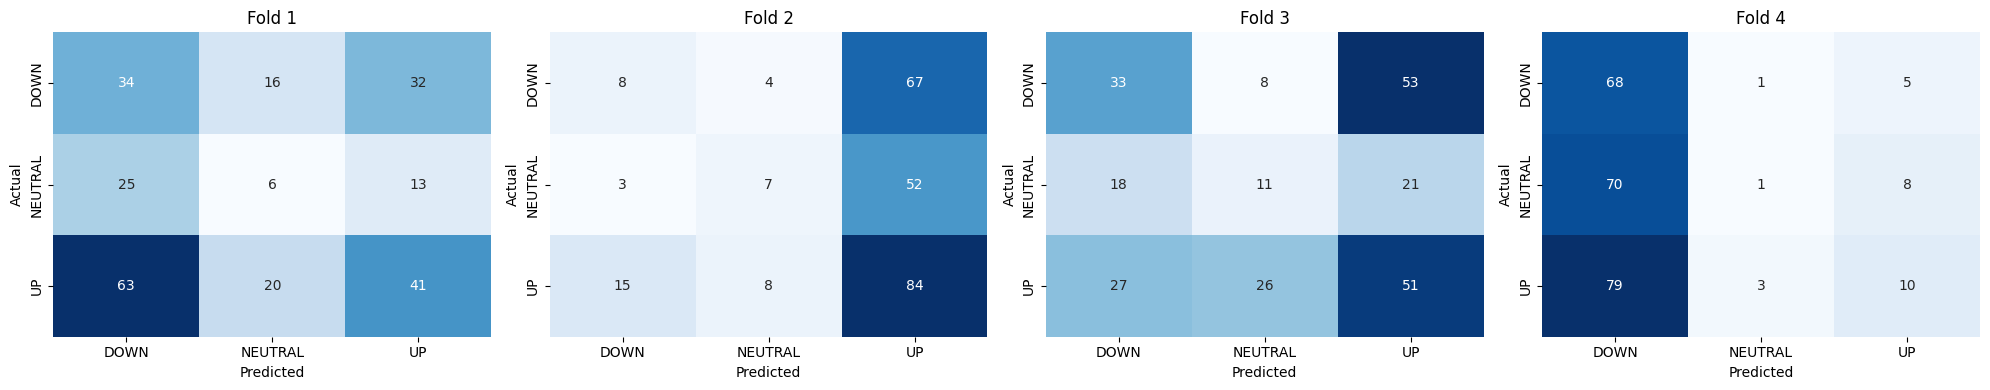

In [7]:
preds = pd.read_csv("../results/rf_predictions.csv")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
labels = ['DOWN', 'NEUTRAL', 'UP']
for i, fold in enumerate(sorted(preds['fold'].unique())):
    fold_preds = preds[preds['fold'] == fold]
    cm = confusion_matrix(fold_preds['Actual'], fold_preds['Predicted'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels, cbar=False)
    axes[i].set_title(f"Fold {fold}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

## Notes
- Best hyperparameters vary somewhat fold to fold, but `max_depth=5` and
  `class_weight='balanced'` / `'balanced_subsample'` are consistently
  selected — the model is being kept shallow and imbalance-aware across
  regimes.
- Fold 4 is the weak point: high `recall_down` alongside very low
  `recall_up`/`recall_neutral` indicates the model collapsed toward
  predicting DOWN almost every day that period, rather than genuinely
  discriminating direction. See the XGBoost notebook for how the more
  complex model handles this same fold.